# Imports

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

TECNICA_ATUAL = "SMOTE" 
PASTA_DADOS = os.path.join("..", "PreProcessing", TECNICA_ATUAL)

NOME_X_TRAIN = "X_train_pronto_SMOTE.csv"
NOME_Y_TRAIN = "y_train_pronto_SMOTE.csv"
NOME_X_TEST  = "X_test_pronto_SMOTE.csv"
NOME_Y_TEST  = "y_test_pronto_SMOTE.csv"

print(f"Treinamento STACKING (Meta-Aprendizado) - Dados: {TECNICA_ATUAL}")

Treinamento STACKING (Meta-Aprendizado) - Dados: SMOTE


# Carregamento

In [2]:
try:
    X_train = pd.read_csv(os.path.join(PASTA_DADOS, NOME_X_TRAIN))
    y_train = pd.read_csv(os.path.join(PASTA_DADOS, NOME_Y_TRAIN)).values.ravel()
    X_test = pd.read_csv(os.path.join(PASTA_DADOS, NOME_X_TEST))
    y_test = pd.read_csv(os.path.join(PASTA_DADOS, NOME_Y_TEST)).values.ravel()
    print("Dados carregados com sucesso!")
except Exception as e:
    print(f"Erro ao ler arquivos: {e}")

Dados carregados com sucesso!


# Treinamento e Arquitetura do Stacking

In [3]:
estimadores_base = [
    ('svm', SVC(C=10, kernel='rbf', probability=True, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=150, max_depth=10, random_state=42)),
    ('mlp', MLPClassifier(hidden_layer_sizes=(100, 50), activation='relu', solver='adam', max_iter=800, random_state=42))
]

meta_modelo = LogisticRegression(max_iter=1000, random_state=42)

stacking_clf = StackingClassifier(
    estimators=estimadores_base,
    final_estimator=meta_modelo,
    cv=3, # Usa validação cruzada interna para evitar que o meta-modelo decore as respostas
    n_jobs=-1
)

print("Treinando a Camada 1 e a Camada 2")
stacking_clf.fit(X_train, y_train)

print("Treinamento do Stacking Concluído!")

Treinando a Camada 1 e a Camada 2
Treinamento do Stacking Concluído!


# Avaliação

--- Relatório de Classificação ---
              precision    recall  f1-score   support

Saudável (0)       0.94      0.87      0.90       138
 Benigno (1)       0.81      0.85      0.83       142
  Câncer (2)       0.07      0.08      0.07        13

    accuracy                           0.83       293
   macro avg       0.60      0.60      0.60       293
weighted avg       0.84      0.83      0.83       293



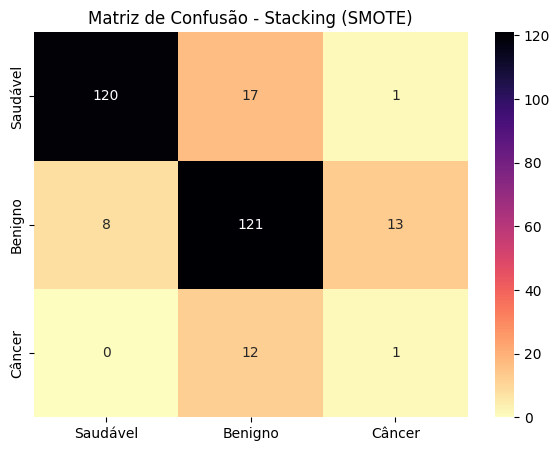

💾 Modelo salvo em: ..\PreProcessing\SMOTE\modelo_stacking_smote.pkl


In [4]:
y_pred = stacking_clf.predict(X_test)

print("--- Relatório de Classificação ---")
print(classification_report(y_test, y_pred, target_names=['Saudável (0)', 'Benigno (1)', 'Câncer (2)']))

plt.figure(figsize=(7, 5))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='magma_r', 
            xticklabels=['Saudável', 'Benigno', 'Câncer'], yticklabels=['Saudável', 'Benigno', 'Câncer'])
plt.title(f"Matriz de Confusão - Stacking ({TECNICA_ATUAL})")
plt.show()

# Salvando
caminho_modelo = os.path.join(PASTA_DADOS, f'modelo_stacking_{TECNICA_ATUAL.lower()}.pkl')
joblib.dump(stacking_clf, caminho_modelo)
print(f"💾 Modelo salvo em: {caminho_modelo}")